# Pistachio Dataset: EDA and Classification Solution
Используем **16‑Attribute Pistachio Dataset** с Kaggle. Набор содержит морфологические характеристики фисташек двух сортов и целевую переменную `target` (0 — Siirt, 1 — Kirmizi).

В этом ноутбуке:
1. Загрузим данные и посмотрим основные сведения.
2. Проведём разведочный анализ (EDA).
3. Построим модель `RandomForestClassifier`, оценим качество с кросс‑валидацией.
4. Обучим модель на всех обучающих данных и предскажем ответы для теста.
5. Сохраним файл `answers.csv` с корректным заголовком **`target`**.


In [74]:

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

display(train_df.head())
print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")


,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,roundness,compactness,shapefactor_1,shapefactor_2,shapefactor_3,shapefactor_4,target
0,75516,1731.4840,411.7352,245.7620,0.8023,310.0806,0.9148,82546,0.7169,1.6753,0.3165,0.7531,0.0055,0.0033,0.5672,0.9502,1
1,98903,1374.4370,477.2451,269.7676,0.8249,354.8622,0.9585,103181,0.7679,1.7691,0.6579,0.7436,0.0048,0.0027,0.5529,0.9781,0
2,84746,1311.1570,482.7735,235.9040,0.8725,328.4843,0.9121,92914,0.7162,2.0465,0.6195,0.6804,0.0057,0.0028,0.4630,0.9474,1
3,98184,1463.1680,434.3769,292.6472,0.7390,353.5700,0.9543,102890,0.7316,1.4843,0.5763,0.8140,0.0044,0.0030,0.6625,0.9834,0
4,94170,1267.7271,440.1109,278.4162,0.7745,346.2672,0.9643,97656,0.6836,1.5808,0.7363,0.7868,0.0047,0.0030,0.6190,0.9785,0


Train shape: (1288, 17), Test shape: (430, 16)


Target distribution:
 target
0    1232
1     916
Name: count, dtype: int64


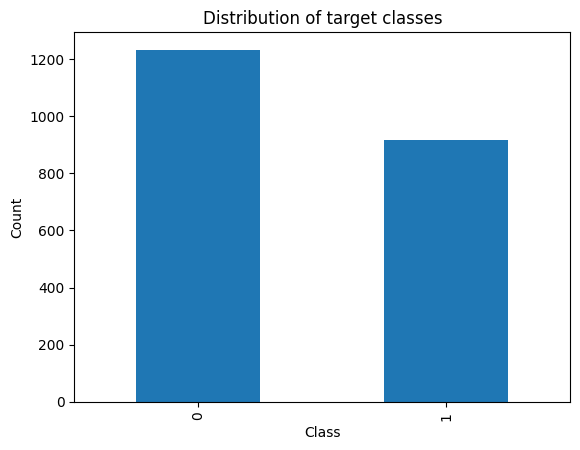

,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,roundness,compactness,shapefactor_1,shapefactor_2,shapefactor_3,shapefactor_4,target
count,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000,2148.000000
mean,79950.655493,1425.971751,446.248968,238.311842,0.840219,317.919173,0.940093,85015.839851,0.716067,1.898154,0.569172,0.713077,0.005701,0.003017,0.510461,0.955239,0.426443
std,13121.737799,375.565503,32.445304,30.310695,0.048759,26.908600,0.050452,13154.919327,0.052532,0.240100,0.212760,0.044547,0.000817,0.000340,0.063942,0.051840,0.494675
min,29808.000000,858.363000,320.344500,133.509600,0.504900,194.814600,0.588000,37935.000000,0.427200,1.158500,0.062800,0.476000,0.004000,0.002400,0.226600,0.620400,0.000000
25%,71936.750000,1170.996250,426.508750,217.875825,0.817500,302.642850,0.919850,76467.000000,0.687000,1.736375,0.371250,0.681550,0.005200,0.002800,0.464475,0.944000,0.000000
50%,79905.500000,1262.785500,448.574750,236.416350,0.849650,318.965300,0.954150,85075.500000,0.726500,1.896250,0.643400,0.710700,0.005600,0.003000,0.505150,0.973100,0.000000
75%,89030.500000,1607.906250,468.509400,257.760150,0.875200,336.685525,0.976925,93893.500000,0.753600,2.067025,0.744125,0.741650,0.006100,0.003200,0.550075,0.987300,1.000000
max,124008.000000,2755.049100,541.966100,383.046100,0.946000,397.356100,0.995100,132478.000000,0.820400,3.085800,0.933600,0.877900,0.013100,0.005300,0.770600,0.999000,1.000000


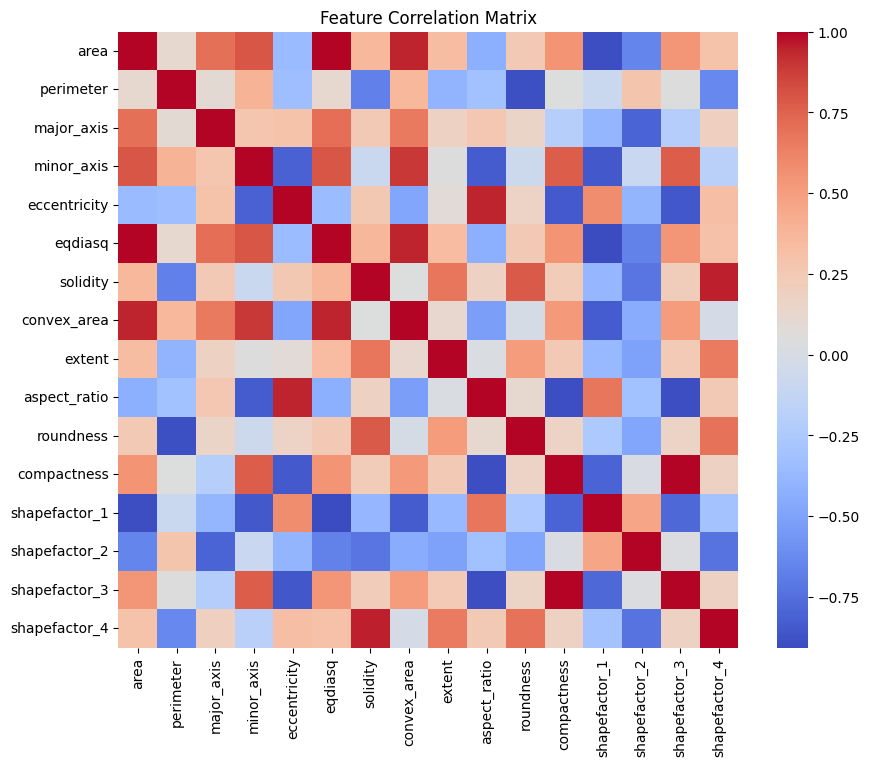

In [54]:

# Распределение целевого признака
target_counts = train_df['target'].value_counts()
print("Target distribution:\n", target_counts)
target_counts.plot(kind='bar', title='Distribution of target classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Основные статистики
display(train_df.describe())

# Корреляционная матрица
plt.figure(figsize=(10,8))
sns.heatmap(train_df.drop(columns=['target']).corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix')
plt.show()


In [55]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

In [56]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

def feature_selection_pca_rf(X, y, k_best=10, n_pca=5, n_splits=20, random_state=42):
    """
    Пайплайн: отбор фич -> PCA -> RandomForest с 20-фолдовой кросс-валидацией.
    
    Parameters:
        X: np.ndarray, shape (n_samples, n_features)
        y: np.ndarray, shape (n_samples,)
        k_best: int, сколько признаков выбрать на первом этапе
        n_pca: int, сколько компонент оставить после PCA
        n_splits: int, количество фолдов для кросс-валидации
        random_state: int, random seed

    Returns:
        mean_score: float, среднее качество по фолдам
        feature_importances: np.ndarray, важности признаков после RandomForest
    """
    # 1. Отбор признаков
    select = SelectKBest(score_func=f_classif, k=k_best)
    # 2. PCA
    pca = PCA(n_components=n_pca, random_state=random_state)
    # 3. RandomForest
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
    # Пайплайн
    pipeline = Pipeline([
        ('pca', pca),
        ('rf', rf)
    ])
    # Кросс-валидация
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"Mean CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

    # Обучим на всех данных для получения важностей признаков (после PCA)
    pipeline.fit(X, y)
    # Важности признаков после PCA — это важности компонент, а не исходных признаков!
    if hasattr(pipeline.named_steps['rf'], 'feature_importances_'):
        feature_importances = pipeline.named_steps['rf'].feature_importances_
        print(f"Feature importances (after PCA): {feature_importances}")
    else:
        feature_importances = None

    return pipeline

In [57]:
X = train_df.drop(columns=['target'])
y = train_df['target']

In [62]:
best_model = feature_selection_pca_rf(X, y, k_best=16, n_pca=16, n_splits=10)

Mean CV accuracy: 0.8799 ± 0.0293
Feature importances (after PCA): [0.29359916 0.06816481 0.03216756 0.12930306 0.04683545 0.04466848
 0.03278916 0.03002577 0.04782426 0.04733087 0.03978175 0.04057288
 0.05806397 0.03747869 0.02688965 0.02450446]


In [59]:



# model = RandomForestClassifier(
#     n_estimators=400,
#     max_depth=None,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     random_state=42,
#     n_jobs=-1
# )

# param_dist = {
#     'n_estimators': randint(100, 500),
#     'max_depth': randint(10, 50),
#     'min_samples_split': randint(2, 11)
# }

# # Настройка RandomizedSearchCV
# random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=100, cv=5, random_state=42)

# # Обучение
# random_search.fit(X, y)

# # Лучшая комбинация гиперпараметров
# best_params = random_search.best_params_

# best_model = RandomForestClassifier(**best_params)


In [60]:
# best_params

In [72]:

# Обучение на всех данных
# best_model.fit(X, y)

# Предсказания
test_pred = best_model.predict(test_df)
test_pred = np.where(test_pred == 0, 1, 0)

# Сохранение ответа
answers = pd.DataFrame({'target': test_pred})
answers.to_csv('answers_forest.csv', index=False, header=False)
answers.head()


,target
0,0
1,0
2,1
3,0
4,0


Готово! Файл **`answers.csv`** сохранён в той же директории и содержит столбец `target` с предсказанными классами для тестового множества.